In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

def print_keys(df_path):
    with pd.HDFStore(df_path, mode='r') as store:
        for key in store.keys():
            print(key)
    store.close()

def load_dfs(df_path, keys2load=None):
    """
    Load DataFrames from HDF5 file.
    Uses pd.read_hdf which is more robust for different pandas versions.
    """
    dfs = {}
    for key in keys2load:
        full_key = key + '_0'
        # Use pd.read_hdf directly - it handles format differences better
        dfs[key] = pd.read_hdf(df_path, key=full_key)
    return dfs


ModuleNotFoundError: No module named 'numpy'

In [ ]:
df_path = "eshower_mc.df"

print_keys(df_path)
dfs = load_dfs(df_path, keys2load=["eshower"])
df = dfs["eshower"]


NameError: name 'print_keys' is not defined

In [ ]:
df.head()

trackScore         shw  \
                                                                       truth   
                                                                           p   
                                                                         pdg   
__ntuple entry rec.slc..index rec.slc.reco.pfp..index                          
34       0     0              0                         0.445735          22   
                              1                         0.381566          22   
                              2                         0.612031        2212   
                              3                         0.470349        2212   
                              4                        -5.000000 -2147483648   

                                                                  \
                                                      open_angle   
                                                                   
                                                                   
__ntuple entry rec.slc..index rec.slc.reco.pfp..index              
34       0     0              0                         0.120986   
                              1                         0.182602   
                              2                         0.014899   
                              3                         0.178360   
                              4                        -5.000000   

                                                                        \
                                                      bestplane_energy   
                                                                         
                                                                         
__ntuple entry rec.slc..index rec.slc.reco.pfp..index                    
34       0     0              0                               0.125702   
                              1                               0.074963   
                              2                               0.108383   
                              3                               0.023385   
                              4                              -5.000000   

                                                                      \
                                                      bestplane_dEdx   
                                                                       
                                                                       
__ntuple entry rec.slc..index rec.slc.reco.pfp..index                  
34       0     0              0                             4.085492   
                              1                             3.565100   
                              2                            27.635866   
                              3                             3.137689   
                              4                            -5.000000   

                                                                      \
                                                      conversion_gap   
                                                                       
                                                                       
__ntuple entry rec.slc..index rec.slc.reco.pfp..index                  
34       0     0              0                             0.482760   
                              1                            18.113737   
                              2                             0.520067   
                              3                             2.191522   
                              4                            -5.000000   

                                                                           \
                                                            dir             
                                                              x         y   
                                                                            
__ntuple entry rec.slc..index rec.slc.reco.pfp..index                       
34  

Shower confusion matrix (counts): True (rows) -> Reconstructed (columns)
col_0     Electron    Muon   Other  Photon  Pion  Proton    Total
row_0                                                            
Electron     18062      15     500   17467   397     811    37252
Kaon             4       2       1       3     1       1       12
Muon        367533  536080    3618   28252  2156    2977   940616
Neutron          1       0       0       2     0       0        3
Other           65       2  163114      55     8     105   163349
Photon       11435      45     619   15025   576     713    28413
Pion          1031     202      86    1077   388     129     2913
Proton        3406     886    1349    2676   499    3697    12513
Total       401537  537232  169287   64557  4025    8433  1185071

Shower confusion matrix (row-normalized, True -> Reco fraction):
col_0     Electron    Muon   Other  Photon    Pion  Proton
row_0                                                     
Electron    0.484

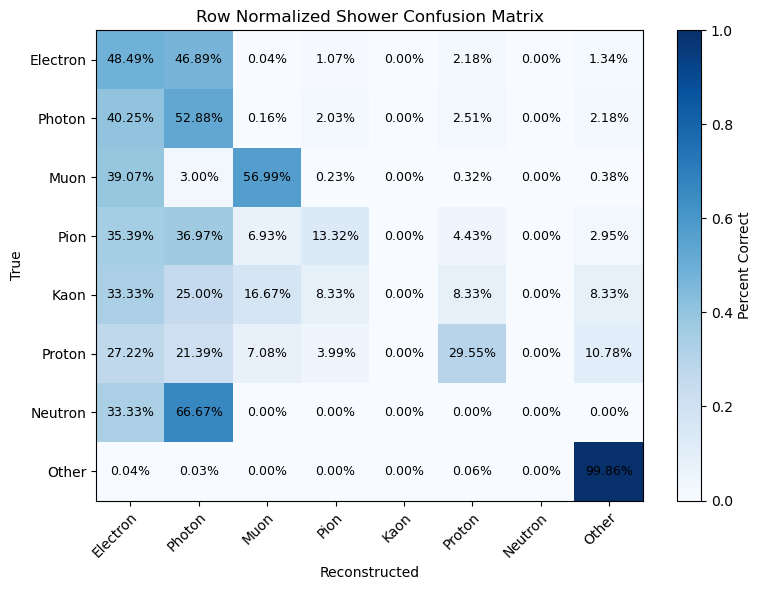

In [ ]:
# Primary shower info is already in the dataframe as 'primshw' columns
# Map old column names to new MultiIndex structure:
df['leading_shower_energy'] = df['primshw', 'shw', 'maxplane_energy', '', '', '']
df['leading_shower_length'] = df['primshw', 'shw', 'len', '', '', '']
df['leading_shower_dEdx'] = df['primshw', 'shw', 'maxplane_dEdx_new', '', '', '']
df['leading_shower_pdg'] = df['primshw', 'shw', 'truth', 'p', 'pdg', '']  # if truth matching exists
df['leading_shower_trackScore'] = df['primshw', 'trackScore', '', '', '', '']
df['leading_shower_openAngle'] = df['primshw', 'shw', 'open_angle', '', '', '']
df['leading_shower_conversion_gap'] = df['primshw', 'shw', 'conversion_gap', '', '', '']
df['leading_shower_reco_pdg'] = df['primshw', 'razzled', 'pdg', '', '', '']
df['leading_shower_reco_electron_score'] = df['primshw', 'razzled', 'electronScore', '', '', '']
df['leading_shower_reco_photon_score'] = df['primshw', 'razzled', 'photonScore', '', '', '']
df['leading_shower_reco_muon_score'] = df['primshw', 'razzled', 'muonScore', '', '', '']
df['leading_shower_reco_pion_score'] = df['primshw', 'razzled', 'pionScore', '', '', '']
df['leading_shower_reco_proton_score'] = df['primshw', 'razzled', 'protonScore', '', '', '']

# Primary track info is already in the dataframe as 'primtrk' columns
df['longest_track_length'] = df['primtrk', 'trk', 'len', '', '', '']
df['longest_track_pdg'] = df['primtrk', 'trk', 'truth', 'p', 'pdg', '']  # if truth matching exists
df['longest_track_trackScore'] = df['primtrk', 'trackScore', '', '', '', '']
df['longest_track_reco_pdg'] = df['primtrk', 'trk', 'dazzle', 'pdg', '', '']
df['longest_track_reco_muon_score'] = df['primtrk', 'trk', 'dazzle', 'muonScore', '', '']
df['longest_track_reco_pion_score'] = df['primtrk', 'trk', 'dazzle', 'pionScore', '', '']
df['longest_track_reco_proton_score'] = df['primtrk', 'trk', 'dazzle', 'protonScore', '', '']

# Slice-level info is already in the dataframe
df['nu_score'] = df['slc', 'nu_score', '', '', '', '']
df['barycenterFM_flashTime'] = df['slc', 'barycenterFM', 'flashTime', '', '', '']
df['barycenterFM_score'] = df['slc', 'barycenterFM', 'score', '', '', '']
df['opflash_T0'] = df['slc', 'correctedOpFlash', 'OpFlashT0', '', '', '']
df['opflash_T0Corrected'] = df['slc', 'correctedOpFlash', 'OpFlashT0Corrected', '', '', '']

In [ ]:


# Confusion matrix: true particle (leading shower) -> reconstructed particle (leading shower)
# Map PDG codes to particle labels (aligned with your masks)
def pdg_to_label(pdg_series):
    """Map PDG codes to particle name; non-standard values -> 'Other'."""
    labels = pd.Series(index=pdg_series.index, dtype=object)
    labels[:] = 'Other'
    labels[pdg_series.isin([11, -11])] = 'Electron'
    labels[pdg_series == 22] = 'Photon'
    labels[pdg_series.isin([13, -13])] = 'Muon'
    labels[pdg_series.isin([211, -211])] = 'Pion'
    labels[pdg_series.isin([321, -321])] = 'Kaon'
    labels[pdg_series.isin([2212, -2212])] = 'Proton'
    labels[pdg_series.isin([2112, -2112])] = 'Neutron'
    return labels

true_labels = pdg_to_label(df['leading_shower_pdg'])
reco_labels = pdg_to_label(df['leading_shower_reco_pdg'])

# Raw counts: rows = true, columns = reconstructed
confusion_counts = pd.crosstab(true_labels, reco_labels, margins=True, margins_name='Total')
print("Shower confusion matrix (counts): True (rows) -> Reconstructed (columns)")
print(confusion_counts)

# Row-normalized: fraction of each true type reconstructed as each reco type (efficiency per true type)
confusion_norm = pd.crosstab(true_labels, reco_labels, normalize='index')
confusion_norm = confusion_norm.round(4)
print("\nShower confusion matrix (row-normalized, True -> Reco fraction):")
print(confusion_norm)

# Summary for true electrons: how many reconstructed as e, gamma, pi, etc.
print("\n--- True electron showers: reconstructed as ---")
true_e = df['leading_shower_pdg'].isin([11, -11])
print(reco_labels[true_e].value_counts().sort_index())

# Heatmap of row-normalized fractions (each row sums to 1)
cm_plot = pd.crosstab(true_labels, reco_labels, normalize='index')
# Order rows/columns by particle type for readability (same set for rows and columns)
particle_order = ['Electron', 'Photon', 'Muon', 'Pion', 'Kaon', 'Proton', 'Neutron', 'Other']
cm_plot = cm_plot.reindex(index=particle_order, columns=particle_order, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_plot.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(cm_plot.columns)))
ax.set_yticks(np.arange(len(cm_plot.index)))
ax.set_xticklabels(cm_plot.columns)
ax.set_yticklabels(cm_plot.index)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(cm_plot.index)):
    for j in range(len(cm_plot.columns)):
        val = cm_plot.values[i, j]
        txt = f'{val*100:.2f}%' if val > 0 else '0.00%'
        ax.text(j, i, txt, ha="center", va="center", color="black", fontsize=9)
ax.set_xlabel('Reconstructed')
ax.set_ylabel('True')
ax.set_title('Row Normalized Shower Confusion Matrix')
plt.colorbar(im, ax=ax, label='Percent Correct')
plt.tight_layout()
plt.show()

In [11]:
true_electron_shower_mask = df['leading_shower_pdg'].isin([11, -11])
true_photon_shower_mask = df['leading_shower_pdg'].isin([22])
true_muon_shower_mask = df['leading_shower_pdg'].isin([13, -13])
true_pion_shower_mask = df['leading_shower_pdg'].isin([211, -211])
true_kaon_shower_mask = df['leading_shower_pdg'].isin([321, -321])
true_proton_shower_mask = df['leading_shower_pdg'].isin([2212, -2212])
true_neutron_shower_mask = df['leading_shower_pdg'].isin([2112, -2112])

reco_electron_shower_mask = df['leading_shower_reco_pdg'].isin([11, -11])
reco_photon_shower_mask = df['leading_shower_reco_pdg'].isin([22])
reco_muon_shower_mask = df['leading_shower_reco_pdg'].isin([13, -13])
reco_pion_shower_mask = df['leading_shower_reco_pdg'].isin([211, -211])
reco_kaon_shower_mask = df['leading_shower_reco_pdg'].isin([321, -321])
reco_proton_shower_mask = df['leading_shower_reco_pdg'].isin([2212, -2212])
reco_neutron_shower_mask = df['leading_shower_reco_pdg'].isin([2112, -2112])
# electron_slices = df[electron_mask]
# print(f"\nSlices with electron-leading shower: {len(electron_slices)}")

#short_track_mask = df['longest_track_length'] < 200
# short_track_slices = df[short_track_mask]
# print(f"Slices with longest track < 50 cm: {len(short_track_slices)}")

true_electron_track_mask = df['longest_track_pdg'].isin([11, -11])
true_photon_track_mask = df['longest_track_pdg'].isin([22])
true_muon_track_mask = df['longest_track_pdg'].isin([13, -13])
true_pion_track_mask = df['longest_track_pdg'].isin([211, -211])
true_kaon_track_mask = df['longest_track_pdg'].isin([321, -321])
true_proton_track_mask = df['longest_track_pdg'].isin([2212, -2212])
true_neutron_track_mask = df['longest_track_pdg'].isin([2112, -2112])

reco_electron_track_mask = df['longest_track_reco_pdg'].isin([11, -11])
reco_photon_track_mask = df['longest_track_reco_pdg'].isin([22])
reco_muon_track_mask = df['longest_track_reco_pdg'].isin([13, -13])
reco_pion_track_mask = df['longest_track_reco_pdg'].isin([211, -211])
reco_kaon_track_mask = df['longest_track_reco_pdg'].isin([321, -321])
reco_proton_track_mask = df['longest_track_reco_pdg'].isin([2212, -2212])
reco_neutron_track_mask = df['longest_track_reco_pdg'].isin([2112, -2112])

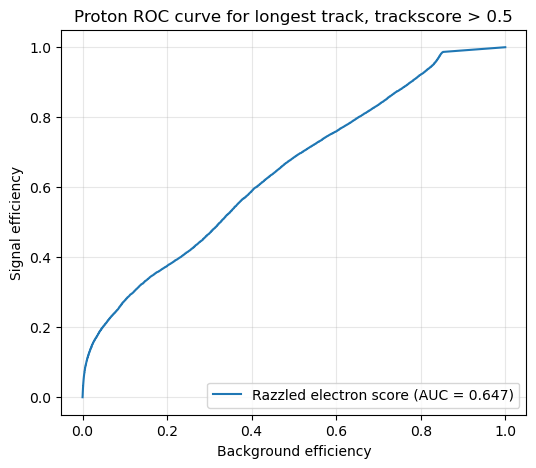

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

# Labels: 1 = true electron, 0 = all others
y_true = true_electron_shower_mask.astype(int)

# Score: how electron-like razzled says the leading shower is
y_score = df['leading_shower_reco_electron_score']
# Drop NaN scores so roc_curve doesn't complain (optional)
valid = y_score.notna()
y_true_v = y_true[valid]
y_score_v = y_score[valid]

fpr, tpr, thresholds = roc_curve(y_true_v, y_score_v)
auc = roc_auc_score(y_true_v, y_score_v)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Razzled electron score (AUC = {auc:.3f})')
#plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Background efficiency')
plt.ylabel('Signal efficiency')
plt.title('Proton ROC curve for longest track, trackscore > 0.5')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
def plot_variable(df, variable, bin_edges, masks, labels, title, xlabel, ylabel, log=False, loc='upper right'):

    plt.hist(df[variable].values, bins=bin_edges, histtype='step', color='black', label='All')
    for mask, label in zip(masks, labels):
        plt.hist(df[mask][variable].values, bins=bin_edges, histtype='step', label=label)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc=loc, fontsize=10)
    plt.grid(True, alpha=0.3)
    if log:
        plt.yscale('log')



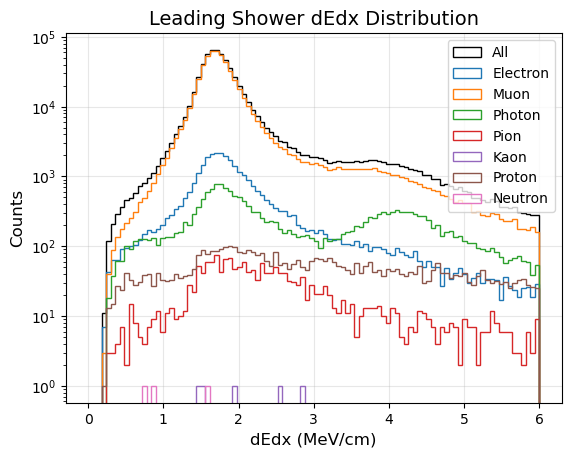

In [14]:
plot_variable(df, 
              'leading_shower_dEdx', 
              np.linspace(0, 6, 101), 
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask], 
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower dEdx Distribution',
              'dEdx (MeV/cm)',
              'Counts',
              log=True)



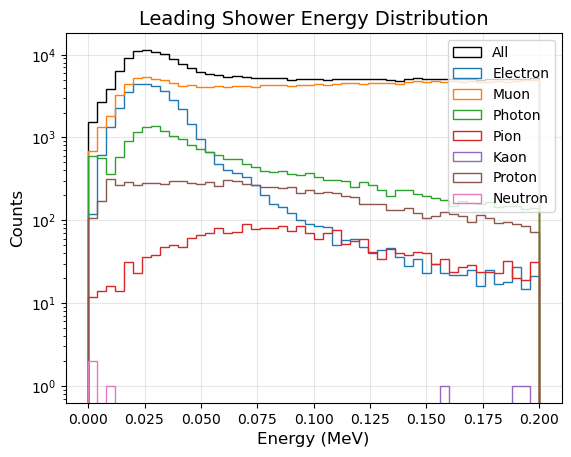

In [15]:
plot_variable(df,   
              'leading_shower_energy', 
              np.linspace(0, 0.2, 51), 
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask], 
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Energy Distribution',
              'Energy (MeV)',
              'Counts',
              log=True)


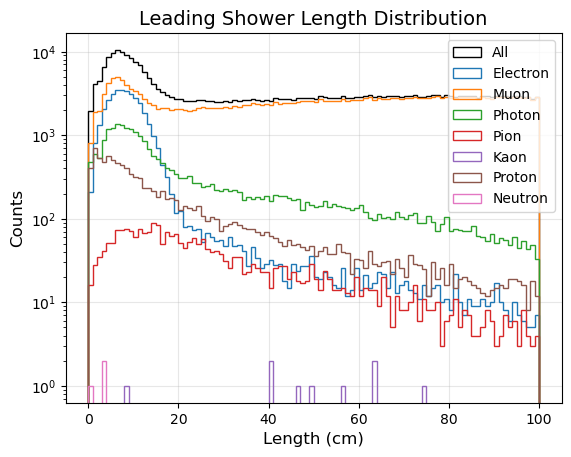

In [16]:

plot_variable(df, 
              'leading_shower_length', 
              np.linspace(0, 100, 101), 
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask], 
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Length Distribution',
              'Length (cm)',
              'Counts',
              log=True)


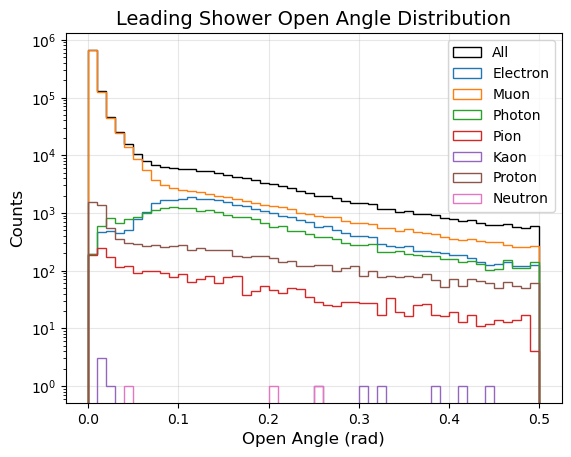

In [17]:
plot_variable(df,
              'leading_shower_openAngle',
              np.linspace(0, 0.5, 51),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Open Angle Distribution',
              'Open Angle (rad)',
              'Counts',
              log=True)



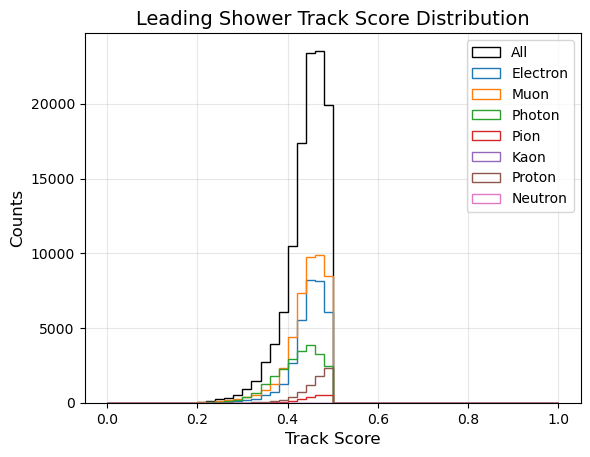

In [18]:
plot_variable(df,
              'leading_shower_trackScore',
              np.linspace(0, 1, 51),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Track Score Distribution',
              'Track Score',
              'Counts',
              log=False)


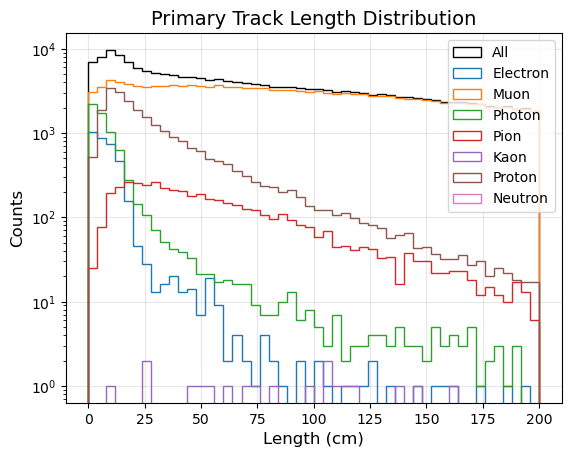

In [19]:
plot_variable(df,
              'longest_track_length',
              np.linspace(0, 200, 51),
              [true_electron_track_mask, true_muon_track_mask, true_photon_track_mask, true_pion_track_mask, true_kaon_track_mask, true_proton_track_mask, true_neutron_track_mask],
              #[electron_shower_mask, muon_shower_mask, photon_shower_mask, pion_shower_mask, kaon_shower_mask, proton_shower_mask, neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Primary Track Length Distribution',
              'Length (cm)',
              'Counts',
              log=True)



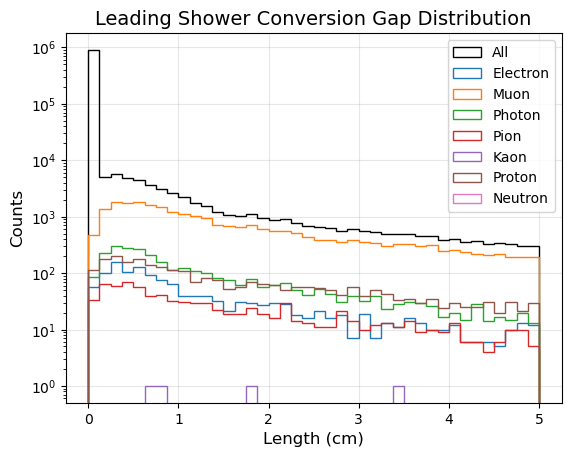

In [20]:
plot_variable(df,
              'leading_shower_conversion_gap',
              np.linspace(0, 5, 41),
              [true_electron_track_mask, true_muon_track_mask, true_photon_track_mask, true_pion_track_mask, true_kaon_track_mask, true_proton_track_mask, true_neutron_track_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Conversion Gap Distribution',
              'Length (cm)',
              'Counts',
              log=True)


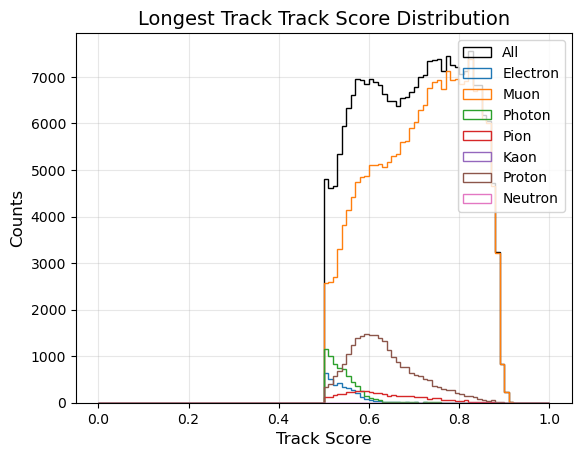

In [21]:
plot_variable(df,
              'longest_track_trackScore',
              np.linspace(0, 1, 101),
              [true_electron_track_mask, true_muon_track_mask, true_photon_track_mask, true_pion_track_mask, true_kaon_track_mask, true_proton_track_mask, true_neutron_track_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Longest Track Track Score Distribution',
              'Track Score',
              'Counts',
              log=False)

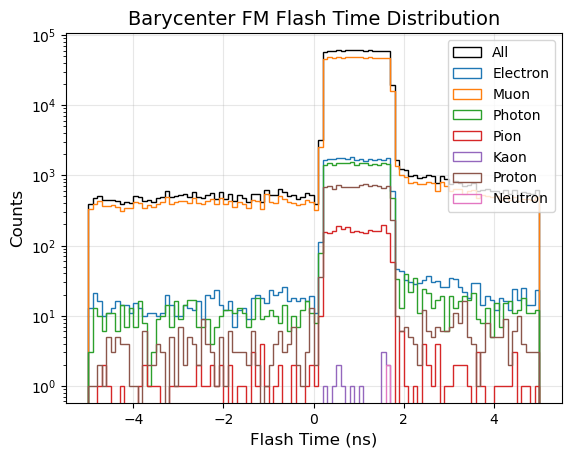

In [22]:
plot_variable(df,
              'barycenterFM_flashTime',
              np.linspace(-5, 5, 101),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Barycenter FM Flash Time Distribution',
              'Flash Time (ns)',
              'Counts',
              log=True)

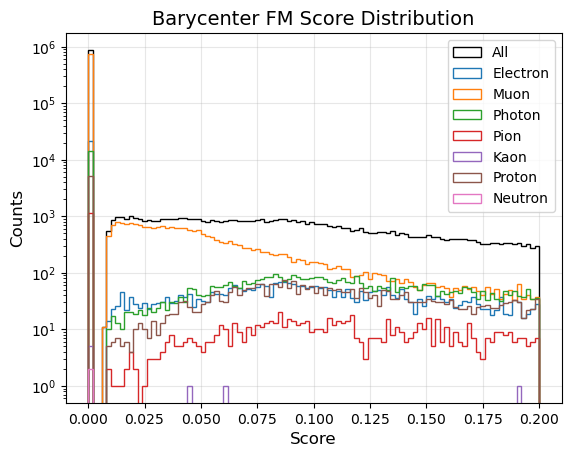

In [23]:
plot_variable(df,
              'barycenterFM_score',
              np.linspace(0, 0.2, 101),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Barycenter FM Score Distribution',
              'Score',
              'Counts',
              log=True)

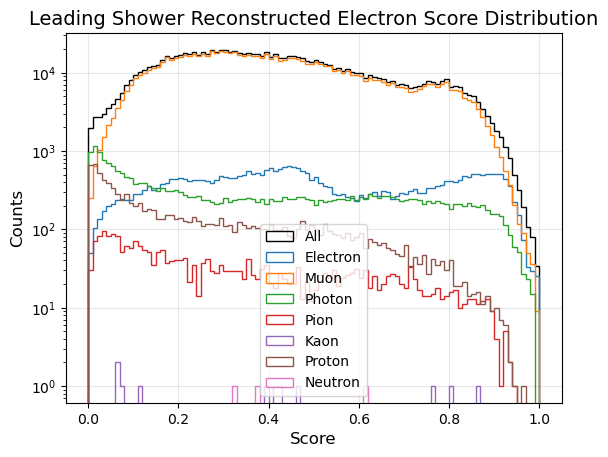

In [24]:
plot_variable(df,
              'leading_shower_reco_electron_score',
              np.linspace(0, 1, 101),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Reconstructed Electron Score Distribution',
              'Score',
              'Counts',
              log=True,
              loc='lower center')

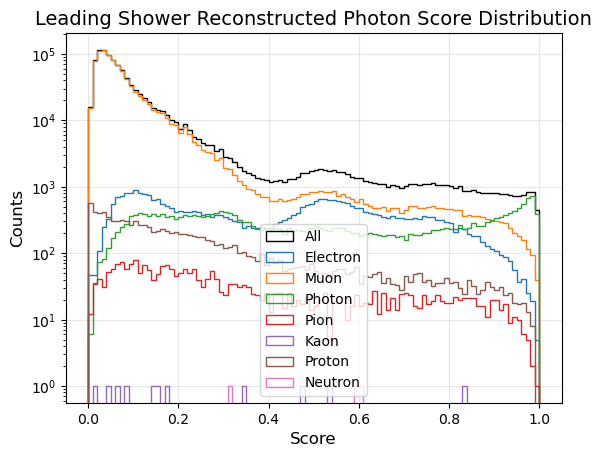

In [25]:
plot_variable(df,
              'leading_shower_reco_photon_score',
              np.linspace(0, 1, 101),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Reconstructed Photon Score Distribution',
              'Score',
              'Counts',
              log=True,
              loc='lower center')

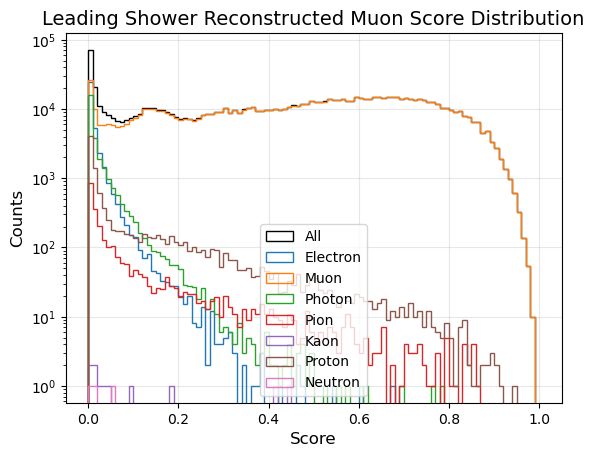

In [26]:
plot_variable(df,
              'leading_shower_reco_muon_score',
              np.linspace(0, 1, 101),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Reconstructed Muon Score Distribution',
              'Score',
              'Counts',
              log=True,
              loc='lower center')

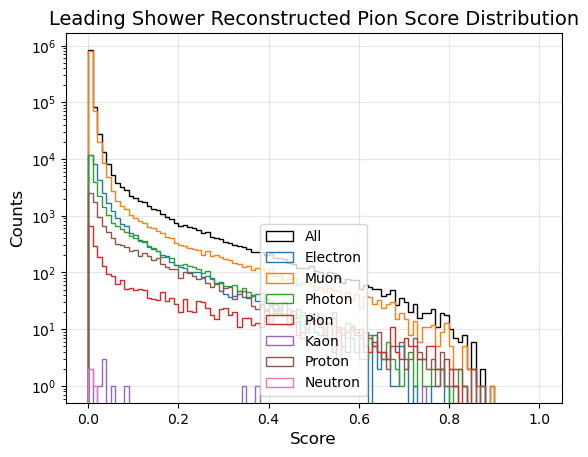

In [27]:
plot_variable(df,
              'leading_shower_reco_pion_score',
              np.linspace(0, 1, 101),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Reconstructed Pion Score Distribution',
              'Score',
              'Counts',
              log=True,
              loc='lower center')

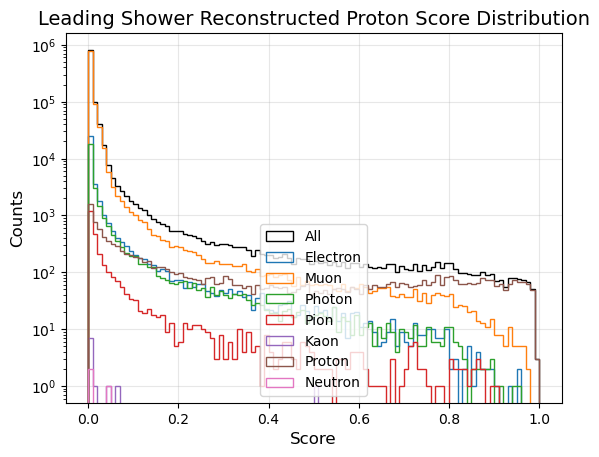

In [28]:
plot_variable(df,
              'leading_shower_reco_proton_score',
              np.linspace(0, 1, 101),
              [true_electron_shower_mask, true_muon_shower_mask, true_photon_shower_mask, true_pion_shower_mask, true_kaon_shower_mask, true_proton_shower_mask, true_neutron_shower_mask],
              ['Electron', 'Muon', 'Photon', 'Pion', 'Kaon', 'Proton', 'Neutron'],
              'Leading Shower Reconstructed Proton Score Distribution',
              'Score',
              'Counts',
              log=True,
              loc='lower center')

In [29]:

def fisher_discriminant(df, variable_list, mask):

    signal_sample = df.loc[mask, variable_list].dropna().values
    background_sample = df.loc[~mask, variable_list].dropna().values

    mu1 = np.mean(signal_sample, axis=0)
    mu0 = np.mean(background_sample, axis=0)

    V1 = np.cov(signal_sample, rowvar=False)
    V0 = np.cov(background_sample, rowvar=False)

    W = V0 + V1
    mu_diff = mu0 - mu1

    a = np.linalg.solve(W, mu_diff)

    return a, signal_sample, background_sample



In [30]:
variable_list = ['leading_shower_dEdx','leading_shower_openAngle']
variable_list = ['leading_shower_dEdx','leading_shower_openAngle', 'leading_shower_length', 'leading_shower_conversion_gap', 'leading_shower_energy', 
                 'nu_score', 'barycenterFM_score', 'leading_shower_reco_electron_score', 'leading_shower_reco_photon_score', 'leading_shower_reco_muon_score',
                 'leading_shower_reco_pion_score', 'leading_shower_reco_proton_score']


a, signal_sample, background_sample = fisher_discriminant(df, variable_list, true_electron_shower_mask)
t_signal = signal_sample @ a
t_background = background_sample @ a



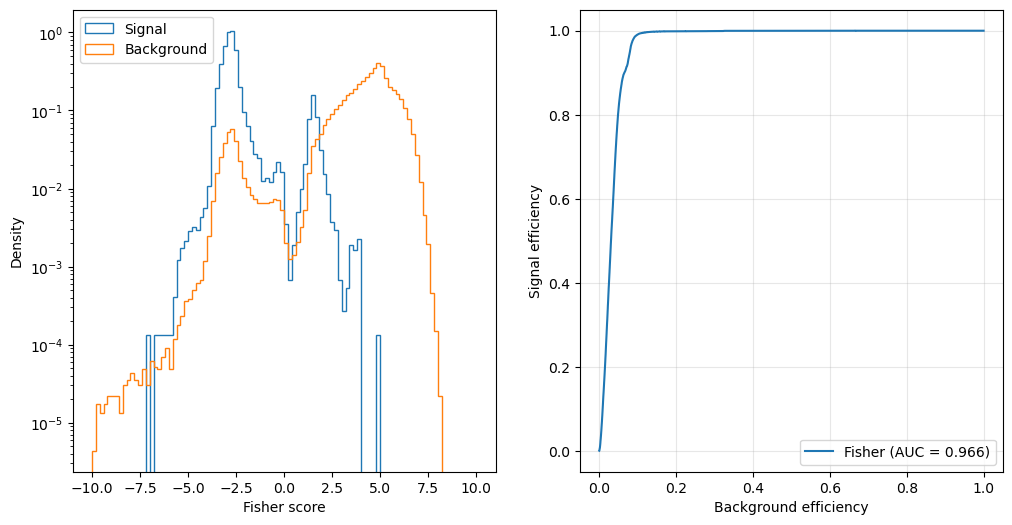

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score

# Labels: 1 = signal, 0 = background
y_true = np.concatenate([np.ones(len(t_signal)), np.zeros(len(t_background))])
# Scores: make "higher = more signal" (negate if signal has lower Fisher score)
y_score = np.concatenate([t_signal, t_background])
if t_signal.mean() < t_background.mean():
    y_score = -y_score

fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

fig, ax = plt.subplots(1,2,figsize=(12,6))

bin_edges = np.linspace(-10,10,101)

ax[0].hist(t_signal, bins=bin_edges, histtype='step', label='Signal', density=True)
ax[0].hist(t_background, bins=bin_edges, histtype='step', label='Background', density=True)
ax[0].set_xlabel('Fisher score')
ax[0].set_ylabel('Density')
ax[0].legend(loc='upper left')
ax[0].set_yscale('log')

ax[1].plot(fpr, tpr, label=f'Fisher (AUC = {auc:.3f})')
#ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('Background efficiency')
ax[1].set_ylabel('Signal efficiency')
ax[1].legend()
ax[1].grid(True, alpha=0.3)


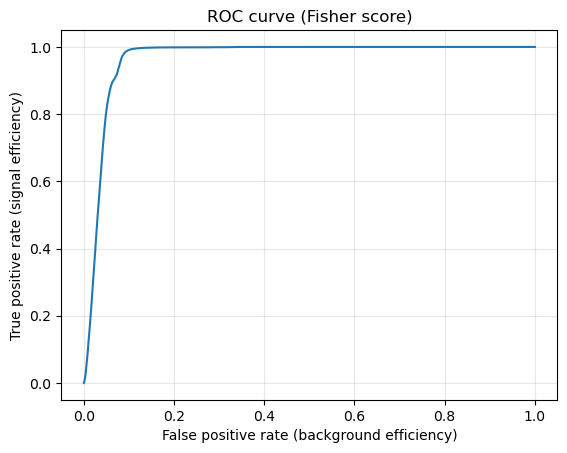

In [32]:

# Combine and get sorted thresholds (or use a fine grid)
all_scores = np.concatenate([t_signal, t_background])
thresholds = np.sort(np.unique(all_scores))
# Optional: add endpoints so curve goes to (0,0) and (1,1)
#thresholds = np.concatenate([[thresholds[0] - 1], thresholds, [thresholds[-1] + 1]])
# e.g. 300 thresholds from min to max
thresholds = np.linspace(all_scores.min() - 1e-9, all_scores.max() + 1e-9, 1000)

# For each threshold: TPR = frac of signal passing, FPR = frac of background passing
# Pass = score <= cut  (signal is lower)
tpr = np.array([(t_signal <= t).mean() for t in thresholds])
fpr = np.array([(t_background <= t).mean() for t in thresholds])

# ROC: x = FPR, y = TPR
plt.plot(fpr, tpr)
plt.xlabel('False positive rate (background efficiency)')
plt.ylabel('True positive rate (signal efficiency)')
plt.title('ROC curve (Fisher score)')
#plt.plot([0, 1], [0, 1], 'k--')
#plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
# print a values as function of total a by the labels they correspond to
print("Weights normalized so that sum = 1")
for i, label in enumerate(variable_list):
    print(f"{label}:{a[i]/np.sum(a):.3f}")


Weights normalized so that sum = 1
leading_shower_dEdx:-0.000
leading_shower_openAngle:0.192
leading_shower_length:-0.002
leading_shower_conversion_gap:0.000
leading_shower_energy:0.254
nu_score:0.701
barycenterFM_score:-0.000
leading_shower_reco_electron_score:0.364
leading_shower_reco_photon_score:0.381
leading_shower_reco_muon_score:-0.566
leading_shower_reco_pion_score:-0.012
leading_shower_reco_proton_score:-0.312


In [34]:
# Valid rows (no NaN in any Fisher variable)
valid = df[variable_list].notna().all(axis=1)
# Fisher score: same sign convention as your ROC (higher = more electron if you negated)
fisher_score = np.full(len(df), np.nan)
fisher_score[valid] = (df.loc[valid, variable_list].values @ a)
# If your ROC used negated scores so that "higher = more signal", negate here too:
#if t_signal.mean() < t_background.mean():
#    fisher_score = -fisher_score

In [58]:
# youden = tpr - fpr

# idx = np.argmax(youden)
# threshold = thresholds[idx]


target_tpr = 0.5
idx = np.argmin(np.abs(tpr - target_tpr))
threshold = thresholds[idx]

#threshold = -1
print(f"Threshold = {threshold}, TPR = {tpr[idx]:.3f}, FPR = {fpr[idx]:.3f}")


fisher_reco_electron = valid & (fisher_score <= threshold)
df['leading_shower_fisher_pdg'] = np.where(fisher_reco_electron, 11, -999)
# Optional: leave non-valid (NaN score) as a different sentinel
df.loc[~valid, 'leading_shower_fisher_pdg'] = np.nan   # or -999

Threshold = -2.7860711692587046, TPR = 0.493, FPR = 0.030


Shower confusion matrix (counts): True (rows) -> Reconstructed (columns)
col_0     Electron    Other    Total
row_0                               
Electron     18361    18891    37252
Kaon             3        9       12
Muon         19506   921110   940616
Neutron          2        1        3
Other           35   163314   163349
Photon       12685    15728    28413
Pion           868     2045     2913
Proton        1442    11071    12513
Total        52902  1132169  1185071

Shower confusion matrix (row-normalized, True -> Reco fraction):
col_0     Electron   Other
row_0                     
Electron    0.4929  0.5071
Kaon        0.2500  0.7500
Muon        0.0207  0.9793
Neutron     0.6667  0.3333
Other       0.0002  0.9998
Photon      0.4465  0.5535
Pion        0.2980  0.7020
Proton      0.1152  0.8848

--- True electron showers: reconstructed as ---
Electron    18361
Other       18891
Name: count, dtype: int64


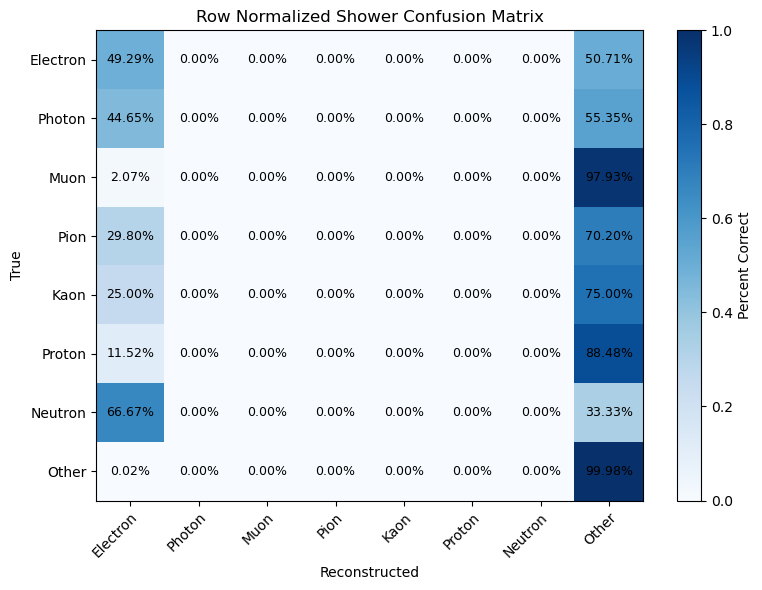

In [59]:

true_labels = pdg_to_label(df['leading_shower_pdg'])
reco_labels = pdg_to_label(df['leading_shower_fisher_pdg'])

# Raw counts: rows = true, columns = reconstructed
confusion_counts = pd.crosstab(true_labels, reco_labels, margins=True, margins_name='Total')
print("Shower confusion matrix (counts): True (rows) -> Reconstructed (columns)")
print(confusion_counts)

# Row-normalized: fraction of each true type reconstructed as each reco type (efficiency per true type)
confusion_norm = pd.crosstab(true_labels, reco_labels, normalize='index')
confusion_norm = confusion_norm.round(4)
print("\nShower confusion matrix (row-normalized, True -> Reco fraction):")
print(confusion_norm)

# Summary for true electrons: how many reconstructed as e, gamma, pi, etc.
print("\n--- True electron showers: reconstructed as ---")
true_e = df['leading_shower_pdg'].isin([11, -11])
print(reco_labels[true_e].value_counts().sort_index())

# Heatmap of row-normalized fractions (each row sums to 1)
cm_plot = pd.crosstab(true_labels, reco_labels, normalize='index')
# Order rows/columns by particle type for readability (same set for rows and columns)
particle_order = ['Electron', 'Photon', 'Muon', 'Pion', 'Kaon', 'Proton', 'Neutron', 'Other']
cm_plot = cm_plot.reindex(index=particle_order, columns=particle_order, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_plot.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(cm_plot.columns)))
ax.set_yticks(np.arange(len(cm_plot.index)))
ax.set_xticklabels(cm_plot.columns)
ax.set_yticklabels(cm_plot.index)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(cm_plot.index)):
    for j in range(len(cm_plot.columns)):
        val = cm_plot.values[i, j]
        txt = f'{val*100:.2f}%' if val > 0 else '0.00%'
        ax.text(j, i, txt, ha="center", va="center", color="black", fontsize=9)
ax.set_xlabel('Reconstructed')
ax.set_ylabel('True')
ax.set_title('Row Normalized Shower Confusion Matrix')
plt.colorbar(im, ax=ax, label='Percent Correct')
plt.tight_layout()
plt.show()


In [60]:
target_tpr_level1 = 0.99
target_tpr_level2 = 0.5

# ============================================================================
# TWO-LEVEL FISHER DISCRIMINANT ANALYSIS
# ============================================================================
# Level 1: Select non-muon showers (signal = non-muons, background = muons)
# Level 2: From non-muons, select electron showers (signal = electrons, background = photons)
# ============================================================================

from sklearn.metrics import roc_curve, roc_auc_score

# ============================================================================
# LEVEL 1: Non-muon vs Muon - CORRECTED THRESHOLD LOGIC
# ============================================================================
print("="*70)
print("LEVEL 1: Non-muon (signal) vs Muon (background)")
print("="*70)

# Signal = non-muons (everything except muons)
# Background = muons
level1_signal_mask = ~true_muon_shower_mask

# Calculate Level 1 Fisher discriminant
a_level1, signal_sample_level1, background_sample_level1 = fisher_discriminant(
    df, variable_list, level1_signal_mask
)

# Calculate Fisher scores
t_signal_level1 = signal_sample_level1 @ a_level1
t_background_level1 = background_sample_level1 @ a_level1

# Calculate ROC for Level 1
y_true_level1 = np.concatenate([np.ones(len(t_signal_level1)), np.zeros(len(t_background_level1))])
y_score_level1 = np.concatenate([t_signal_level1, t_background_level1])

# Determine if we need to negate (signal should have higher scores after negation)
need_negation_level1 = t_signal_level1.mean() < t_background_level1.mean()
if need_negation_level1:
    y_score_level1 = -y_score_level1
    t_signal_level1_roc = -t_signal_level1
    t_background_level1_roc = -t_background_level1
else:
    t_signal_level1_roc = t_signal_level1
    t_background_level1_roc = t_background_level1

fpr_level1, tpr_level1, _ = roc_curve(y_true_level1, y_score_level1)
auc_level1 = roc_auc_score(y_true_level1, y_score_level1)

print(f"Level 1 AUC: {auc_level1:.4f}")
print(f"Level 1 - Signal (non-muon) samples: {len(t_signal_level1)}")
print(f"Level 1 - Background (muon) samples: {len(t_background_level1)}")
print(f"Signal mean score (original): {t_signal_level1.mean():.4f}")
print(f"Background mean score (original): {t_background_level1.mean():.4f}")
print(f"Need negation: {need_negation_level1}")

# Apply Level 1 cut: select non-muons
valid_level1 = df[variable_list].notna().all(axis=1)
fisher_score_level1 = np.full(len(df), np.nan)
fisher_score_level1[valid_level1] = (df.loc[valid_level1, variable_list].values @ a_level1)

# Apply same negation as ROC if needed
if need_negation_level1:
    fisher_score_level1 = -fisher_score_level1

# Select threshold for Level 1 (90% signal efficiency)
# Use the ROC-adjusted scores for threshold calculation
thresholds_level1 = np.linspace(
    np.concatenate([t_signal_level1_roc, t_background_level1_roc]).min() - 1e-9,
    np.concatenate([t_signal_level1_roc, t_background_level1_roc]).max() + 1e-9,
    1000
)

# TPR = fraction of signal passing
# After negation: higher scores = more signal, so we want score >= threshold
if need_negation_level1:
    tpr_level1_thresh = np.array([(t_signal_level1_roc >= t).mean() for t in thresholds_level1])
    fpr_level1_thresh = np.array([(t_background_level1_roc >= t).mean() for t in thresholds_level1])
else:
    tpr_level1_thresh = np.array([(t_signal_level1_roc <= t).mean() for t in thresholds_level1])
    fpr_level1_thresh = np.array([(t_background_level1_roc <= t).mean() for t in thresholds_level1])

idx_level1 = np.argmin(np.abs(tpr_level1_thresh - target_tpr_level1))
threshold_level1 = thresholds_level1[idx_level1]
print(f"Level 1 Threshold: {threshold_level1:.4f} (TPR={tpr_level1_thresh[idx_level1]:.3f}, FPR={fpr_level1_thresh[idx_level1]:.3f})")

# Apply Level 1 selection: keep non-muons (signal)
# CRITICAL FIX: After negation, higher scores = more signal, so use >=
if need_negation_level1:
    passed_level1 = valid_level1 & (fisher_score_level1 >= threshold_level1)
else:
    passed_level1 = valid_level1 & (fisher_score_level1 <= threshold_level1)

print(f"Showers passing Level 1 (non-muon selection): {passed_level1.sum()}")
print(f"  - Expected: ~{int(len(t_signal_level1) * target_tpr_level1)} non-muons + some muons")

# Verify muons are being removed
muons_passing = passed_level1 & true_muon_shower_mask
print(f"  - Muons incorrectly passing Level 1: {muons_passing.sum()} (should be small!)")

# ============================================================================
# LEVEL 2: Electron vs Photon (on Level 1 survivors)
# ============================================================================
print("\n" + "="*70)
print("LEVEL 2: Electron (signal) vs Photon (background) - from Level 1 survivors")
print("="*70)

# Only consider showers that passed Level 1
df_level2 = df[passed_level1].copy()

# Signal = electrons, Background = photons (only from Level 1 survivors)
level2_electron_mask = df_level2['leading_shower_pdg'].isin([11, -11])
level2_photon_mask = df_level2['leading_shower_pdg'].isin([22])

n_electrons_level2 = level2_electron_mask.sum()
n_photons_level2 = level2_photon_mask.sum()
print(f"Level 2 - Electron samples: {n_electrons_level2}")
print(f"Level 2 - Photon samples: {n_photons_level2}")

if n_electrons_level2 < 2 or n_photons_level2 < 2:
    print("WARNING: Not enough samples for Level 2 analysis!")
    df['leading_shower_fisher_twolevel_pdg'] = np.nan
    df.loc[passed_level1, 'leading_shower_fisher_twolevel_pdg'] = -999
else:
    # Calculate Level 2 Fisher discriminant
    a_level2, signal_sample_level2, background_sample_level2 = fisher_discriminant(
        df_level2, variable_list, level2_electron_mask
    )

    # Calculate Fisher scores
    t_signal_level2 = signal_sample_level2 @ a_level2
    t_background_level2 = background_sample_level2 @ a_level2

    # Calculate ROC for Level 2
    y_true_level2 = np.concatenate([np.ones(len(t_signal_level2)), np.zeros(len(t_background_level2))])
    y_score_level2 = np.concatenate([t_signal_level2, t_background_level2])
    
    # Determine if we need to negate
    need_negation_level2 = t_signal_level2.mean() < t_background_level2.mean()
    if need_negation_level2:
        y_score_level2 = -y_score_level2
        t_signal_level2_roc = -t_signal_level2
        t_background_level2_roc = -t_background_level2
    else:
        t_signal_level2_roc = t_signal_level2
        t_background_level2_roc = t_background_level2

    fpr_level2, tpr_level2, _ = roc_curve(y_true_level2, y_score_level2)
    auc_level2 = roc_auc_score(y_true_level2, y_score_level2)

    print(f"Level 2 AUC: {auc_level2:.4f}")
    print(f"Signal mean score (original): {t_signal_level2.mean():.4f}")
    print(f"Background mean score (original): {t_background_level2.mean():.4f}")
    print(f"Need negation: {need_negation_level2}")

    # Apply Level 2 cut: select electrons from Level 1 survivors
    valid_level2 = df_level2[variable_list].notna().all(axis=1)
    fisher_score_level2 = np.full(len(df_level2), np.nan)
    fisher_score_level2[valid_level2] = (df_level2.loc[valid_level2, variable_list].values @ a_level2)
    
    # Apply same negation as ROC if needed
    if need_negation_level2:
        fisher_score_level2 = -fisher_score_level2

    # Select threshold for Level 2 (90% signal efficiency)
    thresholds_level2 = np.linspace(
        np.concatenate([t_signal_level2_roc, t_background_level2_roc]).min() - 1e-9,
        np.concatenate([t_signal_level2_roc, t_background_level2_roc]).max() + 1e-9,
        1000
    )
    
    # TPR = fraction of signal passing
    if need_negation_level2:
        tpr_level2_thresh = np.array([(t_signal_level2_roc >= t).mean() for t in thresholds_level2])
        fpr_level2_thresh = np.array([(t_background_level2_roc >= t).mean() for t in thresholds_level2])
    else:
        tpr_level2_thresh = np.array([(t_signal_level2_roc <= t).mean() for t in thresholds_level2])
        fpr_level2_thresh = np.array([(t_background_level2_roc <= t).mean() for t in thresholds_level2])

    idx_level2 = np.argmin(np.abs(tpr_level2_thresh - target_tpr_level2))
    threshold_level2 = thresholds_level2[idx_level2]
    print(f"Level 2 Threshold: {threshold_level2:.4f} (TPR={tpr_level2_thresh[idx_level2]:.3f}, FPR={fpr_level2_thresh[idx_level2]:.3f})")

    # Apply Level 2 selection: keep electrons from Level 1 survivors
    # CRITICAL FIX: After negation, higher scores = more signal, so use >=
    if need_negation_level2:
        passed_level2_mask = valid_level2 & (fisher_score_level2 >= threshold_level2)
    else:
        passed_level2_mask = valid_level2 & (fisher_score_level2 <= threshold_level2)
    
    # Map back to original dataframe indices using pandas isin
    passed_level2 = df.index.isin(df_level2.index[passed_level2_mask])
    print(f"Showers passing Level 2 (electron selection): {passed_level2.sum()}")
    print(f"  - Expected: ~{int(n_electrons_level2 * target_tpr_level2)} electrons + some photons")

    # ============================================================================
    # FINAL SELECTION: Store results
    # ============================================================================
    # Create final selection: passed both Level 1 and Level 2
    df['leading_shower_fisher_twolevel_pdg'] = np.nan
    df.loc[~valid_level1, 'leading_shower_fisher_twolevel_pdg'] = np.nan
    df.loc[passed_level1, 'leading_shower_fisher_twolevel_pdg'] = -999  # Passed Level 1 but not Level 2
    df.loc[passed_level2, 'leading_shower_fisher_twolevel_pdg'] = 11  # Electron
    
    # Store Fisher scores
    df['leading_shower_fisher_level1_score'] = fisher_score_level1
    df['leading_shower_fisher_level2_score'] = np.nan
    df.loc[passed_level1, 'leading_shower_fisher_level2_score'] = fisher_score_level2
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"Total showers: {len(df)}")
    print(f"Showers passing Level 1 (non-muon): {passed_level1.sum()}")
    print(f"Showers passing Level 2 (electron): {passed_level2.sum()}")
    print(f"Level 1 AUC: {auc_level1:.4f}")
    print(f"Level 2 AUC: {auc_level2:.4f}")

LEVEL 1: Non-muon (signal) vs Muon (background)
Level 1 AUC: 0.9883
Level 1 - Signal (non-muon) samples: 244455
Level 1 - Background (muon) samples: 940616
Signal mean score (original): -3.4093
Background mean score (original): 6.2135
Need negation: True
Level 1 Threshold: -4.9302 (TPR=0.990, FPR=0.109)
Showers passing Level 1 (non-muon selection): 344287
  - Expected: ~242010 non-muons + some muons
  - Muons incorrectly passing Level 1: 102292 (should be small!)

LEVEL 2: Electron (signal) vs Photon (background) - from Level 1 survivors
Level 2 - Electron samples: 37194
Level 2 - Photon samples: 28284
Level 2 AUC: 0.9094
Signal mean score (original): -2.0211
Background mean score (original): 0.3966
Need negation: True
Level 2 Threshold: 2.2070 (TPR=0.510, FPR=0.070)
Showers passing Level 2 (electron selection): 40595
  - Expected: ~18597 electrons + some photons

SUMMARY
Total showers: 1185071
Showers passing Level 1 (non-muon): 344287
Showers passing Level 2 (electron): 40595
Level 1

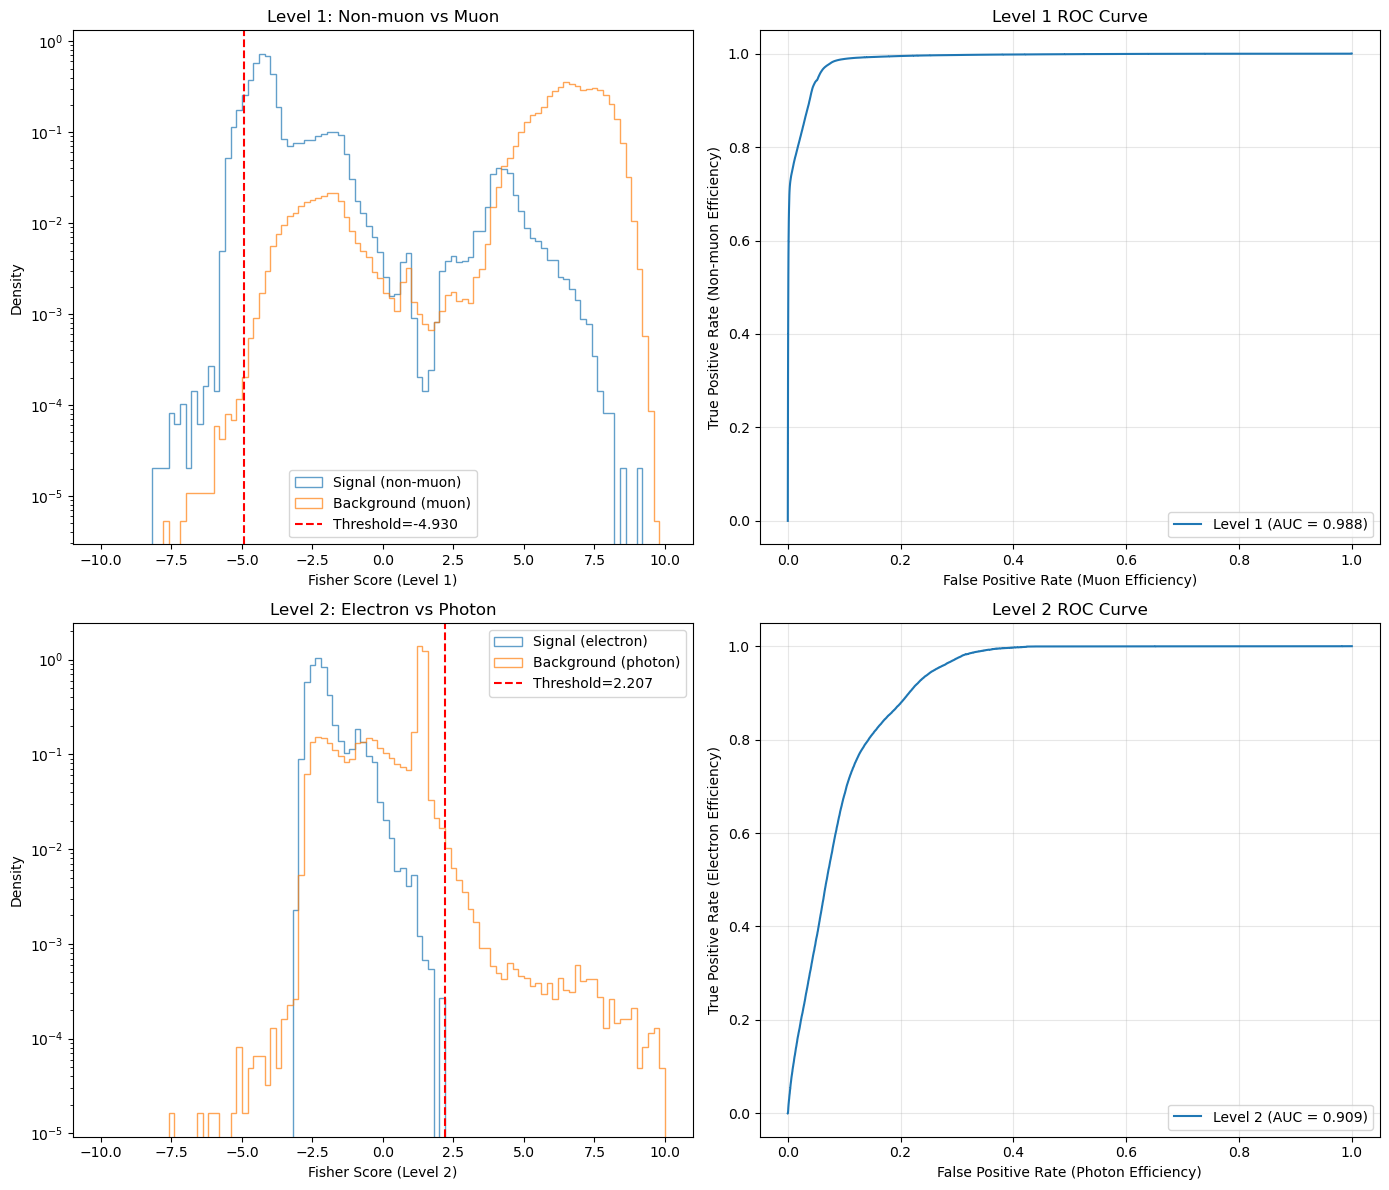

In [61]:

# ============================================================================
# VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Level 1: Score distributions
bin_edges_level1 = np.linspace(-10, 10, 101)
axes[0, 0].hist(t_signal_level1, bins=bin_edges_level1, histtype='step', 
                 label='Signal (non-muon)', density=True, alpha=0.7)
axes[0, 0].hist(t_background_level1, bins=bin_edges_level1, histtype='step', 
                 label='Background (muon)', density=True, alpha=0.7)
axes[0, 0].axvline(threshold_level1, color='r', linestyle='--', label=f'Threshold={threshold_level1:.3f}')
axes[0, 0].set_xlabel('Fisher Score (Level 1)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Level 1: Non-muon vs Muon')
axes[0, 0].legend()
axes[0, 0].set_yscale('log')

# Level 1: ROC curve
axes[0, 1].plot(fpr_level1, tpr_level1, label=f'Level 1 (AUC = {auc_level1:.3f})')
axes[0, 1].set_xlabel('False Positive Rate (Muon Efficiency)')
axes[0, 1].set_ylabel('True Positive Rate (Non-muon Efficiency)')
axes[0, 1].set_title('Level 1 ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Level 2: Score distributions
bin_edges_level2 = np.linspace(-10, 10, 101)
axes[1, 0].hist(t_signal_level2, bins=bin_edges_level2, histtype='step', 
                 label='Signal (electron)', density=True, alpha=0.7)
axes[1, 0].hist(t_background_level2, bins=bin_edges_level2, histtype='step', 
                 label='Background (photon)', density=True, alpha=0.7)
axes[1, 0].axvline(threshold_level2, color='r', linestyle='--', label=f'Threshold={threshold_level2:.3f}')
axes[1, 0].set_xlabel('Fisher Score (Level 2)')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title('Level 2: Electron vs Photon')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')

# Level 2: ROC curve
axes[1, 1].plot(fpr_level2, tpr_level2, label=f'Level 2 (AUC = {auc_level2:.3f})')
axes[1, 1].set_xlabel('False Positive Rate (Photon Efficiency)')
axes[1, 1].set_ylabel('True Positive Rate (Electron Efficiency)')
axes[1, 1].set_title('Level 2 ROC Curve')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Shower confusion matrix (counts): True (rows) -> Reconstructed (columns)
col_0     Electron    Other    Total
row_0                               
Electron     18967    18285    37252
Kaon             0       12       12
Muon         16260   924356   940616
Neutron          2        1        3
Other           20   163329   163349
Photon        4838    23575    28413
Pion           164     2749     2913
Proton         344    12169    12513
Total        40595  1144476  1185071

Shower confusion matrix (row-normalized, True -> Reco fraction):
col_0     Electron   Other
row_0                     
Electron    0.5092  0.4908
Kaon        0.0000  1.0000
Muon        0.0173  0.9827
Neutron     0.6667  0.3333
Other       0.0001  0.9999
Photon      0.1703  0.8297
Pion        0.0563  0.9437
Proton      0.0275  0.9725

--- True electron showers: reconstructed as ---
Electron    18967
Other       18285
Name: count, dtype: int64


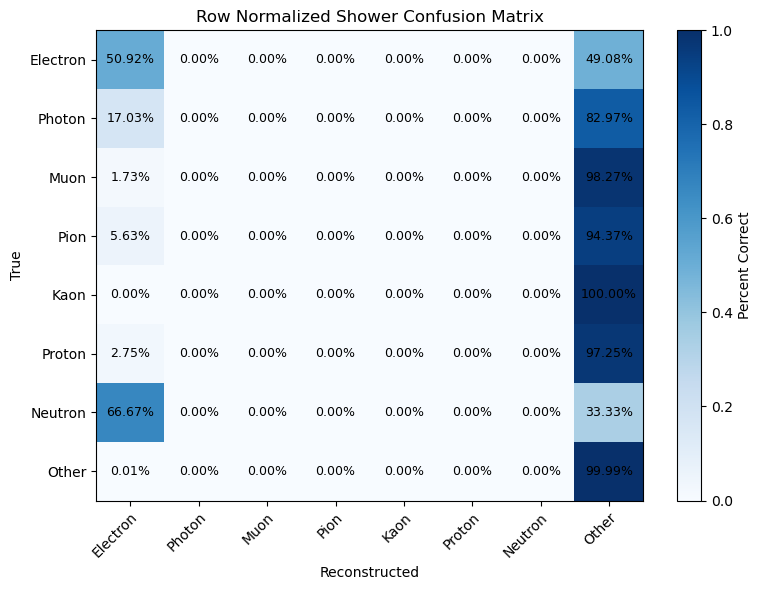

In [62]:

true_labels = pdg_to_label(df['leading_shower_pdg'])
reco_labels = pdg_to_label(df['leading_shower_fisher_twolevel_pdg'])

confusion_counts = pd.crosstab(true_labels, reco_labels, margins=True, margins_name='Total')
print("Shower confusion matrix (counts): True (rows) -> Reconstructed (columns)")
print(confusion_counts)

# Row-normalized: fraction of each true type reconstructed as each reco type (efficiency per true type)
confusion_norm = pd.crosstab(true_labels, reco_labels, normalize='index')
confusion_norm = confusion_norm.round(4)
print("\nShower confusion matrix (row-normalized, True -> Reco fraction):")
print(confusion_norm)

# Summary for true electrons: how many reconstructed as e, gamma, pi, etc.
print("\n--- True electron showers: reconstructed as ---")
true_e = df['leading_shower_pdg'].isin([11, -11])
print(reco_labels[true_e].value_counts().sort_index())

# Heatmap of row-normalized fractions (each row sums to 1)
cm_plot = pd.crosstab(true_labels, reco_labels, normalize='index')
# Order rows/columns by particle type for readability (same set for rows and columns)
particle_order = ['Electron', 'Photon', 'Muon', 'Pion', 'Kaon', 'Proton', 'Neutron', 'Other']
cm_plot = cm_plot.reindex(index=particle_order, columns=particle_order, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_plot.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(cm_plot.columns)))
ax.set_yticks(np.arange(len(cm_plot.index)))
ax.set_xticklabels(cm_plot.columns)
ax.set_yticklabels(cm_plot.index)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(cm_plot.index)):
    for j in range(len(cm_plot.columns)):
        val = cm_plot.values[i, j]
        txt = f'{val*100:.2f}%' if val > 0 else '0.00%'
        ax.text(j, i, txt, ha="center", va="center", color="black", fontsize=9)
ax.set_xlabel('Reconstructed')
ax.set_ylabel('True')
ax.set_title('Row Normalized Shower Confusion Matrix')
plt.colorbar(im, ax=ax, label='Percent Correct')
plt.tight_layout()
plt.show()